In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix
)

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier


import warnings
warnings.filterwarnings("ignore")

/kaggle/input/ana-verse-2-0-h/train.parquet
/kaggle/input/ana-verse-2-0-h/sample_submission.parquet
/kaggle/input/ana-verse-2-0-h/test.parquet


In [2]:
import pandas as pd


train = pd.read_parquet("/kaggle/input/ana-verse-2-0-h/train.parquet")
test = pd.read_parquet("/kaggle/input/ana-verse-2-0-h/test.parquet")
sample_submission = pd.read_parquet("/kaggle/input/ana-verse-2-0-h/sample_submission.parquet")

In [3]:
train.shape
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1639424 entries, 0 to 1639423
Data columns (total 7 columns):
 #   Column  Non-Null Count    Dtype         
---  ------  --------------    -----         
 0   Date    1639424 non-null  datetime64[ns]
 1   X1      1639424 non-null  float64       
 2   X2      1639424 non-null  float64       
 3   X3      1639424 non-null  float64       
 4   X4      1639424 non-null  float64       
 5   X5      1639424 non-null  float64       
 6   target  1639424 non-null  object        
dtypes: datetime64[ns](1), float64(5), object(1)
memory usage: 87.6+ MB


In [4]:
train.isnull().sum().sort_values(ascending=False)

Date      0
X1        0
X2        0
X3        0
X4        0
X5        0
target    0
dtype: int64

In [5]:
feature_cols = ["X1", "X2", "X3", "X4", "X5"]

for col in feature_cols:
    median_val = train[col].median()
    train[col].fillna(median_val, inplace=True)
    test[col].fillna(median_val, inplace=True)

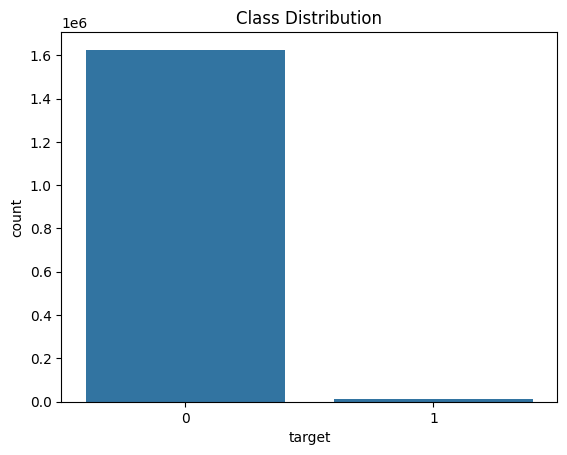

In [6]:
target_col = "target"   # change if needed

sns.countplot(x=train[target_col])
plt.title("Class Distribution")
plt.show()

In [7]:
from lightgbm import LGBMClassifier

model = LGBMClassifier(
    n_estimators=500,
    learning_rate=0.05,
    class_weight="balanced",
    n_jobs=-1
)

In [8]:
num_cols = ["X1", "X2", "X3", "X4", "X5"]

for col in num_cols:
    Q1 = train[col].quantile(0.25)
    Q3 = train[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    train[col] = np.clip(train[col], lower, upper)

In [9]:
train[num_cols].describe()

,X1,X2,X3,X4,X5
count,1.639424e+06,1.639424e+06,1639424.0,1.639424e+06,1.639424e+06
mean,1.134938e+00,5.488299e+00,1.0,1.808049e+00,1.187219e+00
std,1.227826e-01,1.297542e-02,0.0,1.414896e+00,1.304814e+00
min,1.000000e+00,5.456417e+00,1.0,1.000000e+00,0.000000e+00
25%,1.049171e+00,5.480597e+00,1.0,1.000000e+00,0.000000e+00
50%,1.105171e+00,5.488979e+00,1.0,1.000000e+00,6.931472e-01
75%,1.214096e+00,5.496717e+00,1.0,2.718282e+00,2.890372e+00
max,1.461485e+00,5.520897e+00,1.0,5.295705e+00,3.465736e+00


In [10]:
train["sensor_mean"] = train[num_cols].mean(axis=1)
train["sensor_std"]  = train[num_cols].std(axis=1)
train["sensor_max"]  = train[num_cols].max(axis=1)

test["sensor_mean"] = test[num_cols].mean(axis=1)
test["sensor_std"]  = test[num_cols].std(axis=1)
test["sensor_max"]  = test[num_cols].max(axis=1)

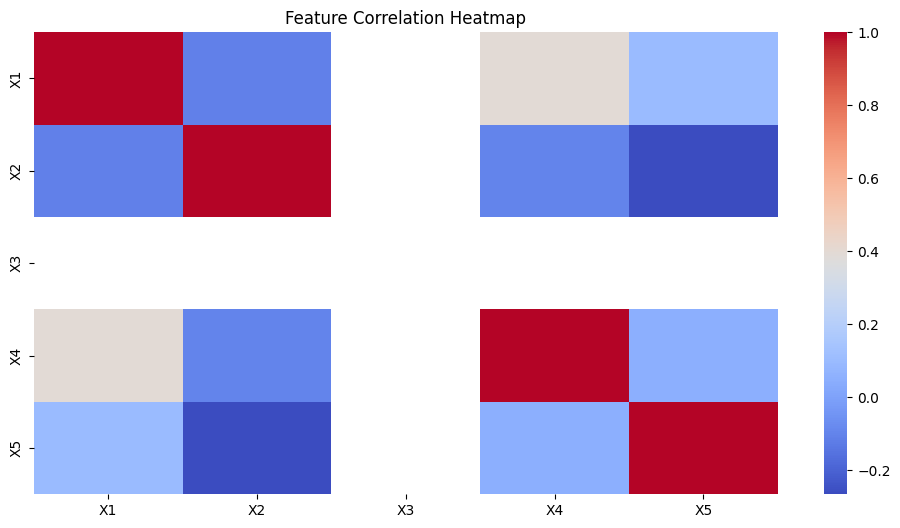

In [11]:
plt.figure(figsize=(12,6))
sns.heatmap(train[num_cols].corr(), cmap="coolwarm")
plt.title("Feature Correlation Heatmap")
plt.show()

In [12]:
X = train.drop(columns=[target_col])
y = train[target_col]

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

In [13]:
sensor_cols = ["X1", "X2", "X3", "X4", "X5"]

for df in [train, test]:
    df["sensor_mean"] = df[sensor_cols].mean(axis=1)
    df["sensor_std"]  = df[sensor_cols].std(axis=1)
    df["sensor_max"]  = df[sensor_cols].max(axis=1)
    df["sensor_min"]  = df[sensor_cols].min(axis=1)

In [14]:
for df in [train, test]:
    df["day"] = df["Date"].dt.day
    df["month"] = df["Date"].dt.month
    df["dayofweek"] = df["Date"].dt.dayofweek

In [15]:
X = train[feature_cols]
y = train["target"]

split_idx = int(len(train) * 0.8)

X_train = X.iloc[:split_idx]
X_val   = X.iloc[split_idx:]

y_train = y.iloc[:split_idx]
y_val   = y.iloc[split_idx:]

In [16]:
feature_cols = [
    "X1", "X2", "X3", "X4", "X5",
    "sensor_mean", "sensor_std", "sensor_max", "sensor_min",
    "day", "month", "dayofweek"
]

In [17]:
import pandas as pd

train = pd.read_parquet("/kaggle/input/ana-verse-2-0-h/train.parquet")
test  = pd.read_parquet("/kaggle/input/ana-verse-2-0-h/test.parquet")

In [18]:
feature_cols = [
    "X1", "X2", "X3", "X4", "X5",
    "sensor_mean", "sensor_std", "sensor_max", "sensor_min",
    "day", "month", "dayofweek"
]

In [19]:
feature_cols = [
    "X1","X2","X3","X4","X5",
    "sensor_mean","sensor_std","sensor_max","sensor_min",
    "day","month","dayofweek"
]

In [20]:
print(train.columns.tolist())

['Date', 'X1', 'X2', 'X3', 'X4', 'X5', 'target']


In [21]:
feature_cols = [
    "X1", "X2", "X3", "X4", "X5",
    "sensor_mean", "sensor_std", "sensor_max", "sensor_min",
    "day", "month", "dayofweek"
]

In [22]:
feature_cols = ["X1", "X2", "X3", "X4", "X5"]

In [23]:
X = train[feature_cols]
y = train["target"]

split_idx = int(len(train) * 0.8)

X_train = X.iloc[:split_idx]
X_val   = X.iloc[split_idx:]

y_train = y.iloc[:split_idx]
y_val   = y.iloc[split_idx:]

In [24]:
X_train.shape, X_val.shape

((1311539, 5), (327885, 5))

In [25]:
print(train.columns.tolist())

['Date', 'X1', 'X2', 'X3', 'X4', 'X5', 'target']


In [26]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

In [27]:
pipe_lr = Pipeline([
    ("scaler", StandardScaler()),
    ("lr", LogisticRegression(max_iter=1000, class_weight="balanced"))
])

pipe_lr.fit(X_train, y_train)
y_pred = pipe_lr.predict(X_val)

print(classification_report(y_val, y_pred))

              precision    recall  f1-score   support

           0       1.00      0.89      0.94    326709
           1       0.03      0.90      0.05      1176

    accuracy                           0.89    327885
   macro avg       0.51      0.89      0.50    327885
weighted avg       1.00      0.89      0.94    327885



In [28]:
from sklearn.svm import LinearSVC
from sklearn.metrics import f1_score

svm = LinearSVC(class_weight="balanced", max_iter=5000)
svm.fit(X_train, y_train)

preds = svm.predict(X_val)
print(f1_score(y_val, preds, average="weighted"))

2.563578831856893e-05


In [29]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import f1_score

# small subsample for feasibility
sample_idx = X_train.sample(20000, random_state=42).index

knn = KNeighborsClassifier(n_neighbors=7)
knn.fit(X_train.loc[sample_idx], y_train.loc[sample_idx])

preds = knn.predict(X_val)
print(f1_score(y_val, preds, average="weighted"))

0.9965499813346294


In [30]:
from sklearn.metrics import classification_report

print(classification_report(y_val, preds))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00    326709
           1       0.51      0.54      0.52      1176

    accuracy                           1.00    327885
   macro avg       0.76      0.77      0.76    327885
weighted avg       1.00      1.00      1.00    327885



In [31]:
from lightgbm import LGBMClassifier
from sklearn.metrics import classification_report, f1_score

lgbm = LGBMClassifier(
    n_estimators=600,
    learning_rate=0.05,
    num_leaves=64,
    min_child_samples=50,
    class_weight="balanced",
    n_jobs=-1
)

lgbm.fit(X_train, y_train)

preds = lgbm.predict(X_val)

print(classification_report(y_val, preds))
print("Weighted F1:", f1_score(y_val, preds, average="weighted"))

[LightGBM] [Info] Number of positive: 12862, number of negative: 1298677
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.034835 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 686
[LightGBM] [Info] Number of data points in the train set: 1311539, number of used features: 5
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
              precision    recall  f1-score   support

           0       1.00      0.97      0.99    326709
           1       0.12      0.95      0.21      1176

    accuracy                           0.97    327885
   macro avg       0.56      0.96      0.60    327885
weighted avg       1.00      0.97      0.98    327885

Weighted F1: 0.9842887120894126


In [32]:
feature_cols = [
    "X1", "X2", "X3", "X4", "X5",
    "sensor_mean", "sensor_std", "sensor_max", "sensor_min",
    "day", "month", "dayofweek"
]

In [33]:
print(train.columns.tolist())

['Date', 'X1', 'X2', 'X3', 'X4', 'X5', 'target']


In [34]:
# Date features
train["Date"] = pd.to_datetime(train["Date"])
test["Date"]  = pd.to_datetime(test["Date"])

for df in [train, test]:
    df["day"] = df["Date"].dt.day
    df["month"] = df["Date"].dt.month
    df["dayofweek"] = df["Date"].dt.dayofweek

# Sensor features
sensor_cols = ["X1", "X2", "X3", "X4", "X5"]

for df in [train, test]:
    df["sensor_mean"] = df[sensor_cols].mean(axis=1)
    df["sensor_std"]  = df[sensor_cols].std(axis=1)
    df["sensor_max"]  = df[sensor_cols].max(axis=1)
    df["sensor_min"]  = df[sensor_cols].min(axis=1)

In [35]:
print(train.columns.tolist())

['Date', 'X1', 'X2', 'X3', 'X4', 'X5', 'target', 'day', 'month', 'dayofweek', 'sensor_mean', 'sensor_std', 'sensor_max', 'sensor_min']


In [36]:
feature_cols = [c for c in train.columns if c not in ["target", "Date"]]

In [37]:
len(feature_cols), feature_cols

(12,
 ['X1',
  'X2',
  'X3',
  'X4',
  'X5',
  'day',
  'month',
  'dayofweek',
  'sensor_mean',
  'sensor_std',
  'sensor_max',
  'sensor_min'])

In [38]:
feature_cols = [c for c in train.columns if c not in ["target", "Date"]]

In [39]:
len(feature_cols), feature_cols

(12,
 ['X1',
  'X2',
  'X3',
  'X4',
  'X5',
  'day',
  'month',
  'dayofweek',
  'sensor_mean',
  'sensor_std',
  'sensor_max',
  'sensor_min'])

In [40]:
X = train[feature_cols]
y = train["target"]

split_idx = int(len(train) * 0.8)

X_train = X.iloc[:split_idx]
X_val   = X.iloc[split_idx:]

y_train = y.iloc[:split_idx]
y_val   = y.iloc[split_idx:]

In [41]:
from lightgbm import LGBMClassifier
from sklearn.metrics import classification_report, f1_score

lgbm = LGBMClassifier(
    n_estimators=600,
    learning_rate=0.05,
    num_leaves=64,
    min_child_samples=50,
    class_weight="balanced",
    n_jobs=-1
)

lgbm.fit(X_train, y_train)

preds = lgbm.predict(X_val)

print(classification_report(y_val, preds))
print("Weighted F1:", f1_score(y_val, preds, average="weighted"))

[LightGBM] [Info] Number of positive: 12862, number of negative: 1298677
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.044872 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1758
[LightGBM] [Info] Number of data points in the train set: 1311539, number of used features: 12
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
              precision    recall  f1-score   support

           0       1.00      0.98      0.99    326709
           1       0.18      0.91      0.30      1176

    accuracy                           0.98    327885
   macro avg       0.59      0.95      0.64    327885
weighted avg       1.00      0.98      0.99    327885

Weighted F1: 0.989655402951867


In [42]:
from sklearn.tree import DecisionTreeClassifier

In [43]:
dt = DecisionTreeClassifier(max_depth=8, class_weight="balanced", random_state=42)
dt.fit(X_train, y_train)

DecisionTreeClassifier(class_weight='balanced', max_depth=8, random_state=42)

In [44]:
from sklearn.metrics import classification_report, f1_score

preds = dt.predict(X_val)
print(classification_report(y_val, preds))
print("Weighted F1:", f1_score(y_val, preds, average="weighted"))

              precision    recall  f1-score   support

           0       1.00      0.96      0.98    326709
           1       0.09      0.97      0.16      1176

    accuracy                           0.96    327885
   macro avg       0.54      0.97      0.57    327885
weighted avg       1.00      0.96      0.98    327885

Weighted F1: 0.9789832307222741


In [45]:
from sklearn.metrics import accuracy_score, f1_score
import pandas as pd

models = {
    "Decision Tree": dt,
    "LightGBM": lgbm
}

results = []

for name, model in models.items():
    pred = model.predict(X_val)
    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_val, pred),
        "F1 (weighted)": f1_score(y_val, pred, average="weighted")
    })

pd.DataFrame(results).sort_values("F1 (weighted)", ascending=False)

,Model,Accuracy,F1 (weighted)
1,LightGBM,0.984476,0.989655
0,Decision Tree,0.964600,0.978983


In [46]:
from sklearn.neighbors import KNeighborsClassifier

sample_idx = X_train.sample(20000, random_state=42).index

knn = KNeighborsClassifier(n_neighbors=7)
knn.fit(X_train.loc[sample_idx], y_train.loc[sample_idx])

KNeighborsClassifier(n_neighbors=7)

In [47]:
from sklearn.metrics import accuracy_score, f1_score
import pandas as pd

# Final models to compare
models = {
    "KNN (subsampled)": knn,
    "Decision Tree": dt,
    "LightGBM": lgbm
}

results = []

for name, model in models.items():
    preds = model.predict(X_val)
    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_val, preds),
        "F1 (weighted)": f1_score(y_val, preds, average="weighted")
    })

pd.DataFrame(results).sort_values("F1 (weighted)", ascending=False)

,Model,Accuracy,F1 (weighted)
0,KNN (subsampled),0.996749,0.996693
2,LightGBM,0.984476,0.989655
1,Decision Tree,0.964600,0.978983


In [48]:
from sklearn.model_selection import StratifiedKFold

In [49]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import f1_score
import numpy as np

# Take a manageable subsample
cv_idx = X_train.sample(200000, random_state=42).index
X_cv = X_train.loc[cv_idx]
y_cv = y_train.loc[cv_idx]

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

f1_scores = []

for train_idx, val_idx in skf.split(X_cv, y_cv):
    X_t, X_v = X_cv.iloc[train_idx], X_cv.iloc[val_idx]
    y_t, y_v = y_cv.iloc[train_idx], y_cv.iloc[val_idx]

    lgbm.fit(X_t, y_t)
    preds = lgbm.predict(X_v)

    f1_scores.append(f1_score(y_v, preds, average="weighted"))

np.mean(f1_scores)

[LightGBM] [Info] Number of positive: 1606, number of negative: 158394
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.005810 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1758
[LightGBM] [Info] Number of data points in the train set: 160000, number of used features: 12
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
[LightGBM] [Info] Number of positive: 1606, number of negative: 158394
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.005630 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1758
[LightGBM] [Info] Number of data points in the train set: 160000, number of used features: 12
[LightGBM] [Info] 

np.float64(0.9920141302110366)

In [50]:
sample_submission = pd.read_parquet(
    "/kaggle/input/ana-verse-2-0-h/sample_submission.parquet"
)

In [51]:
target_col = "target"

In [52]:
from lightgbm import LGBMClassifier

final_lgbm = LGBMClassifier(
    n_estimators=300,
    learning_rate=0.05,
    num_leaves=64,
    min_child_samples=50,
    class_weight="balanced",
    n_jobs=-1,
    random_state=42
)

# Train on full training data
final_lgbm.fit(X, y)

# Create predictions (this defines test_preds)
test_preds = final_lgbm.predict(test[feature_cols])

print("Predictions created:", len(test_preds))

[LightGBM] [Info] Number of positive: 14038, number of negative: 1625386
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.061042 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1761
[LightGBM] [Info] Number of data points in the train set: 1639424, number of used features: 12
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
Predictions created: 409856


In [53]:
import pandas as pd

submission = pd.DataFrame({
    target_col: test_preds
})

submission.to_csv("submission.csv", index=False)

print("submission.csv created successfully")
print(submission.shape)

submission.csv created successfully
(409856, 1)


In [54]:
print(submission.head())
print(submission[target_col].value_counts())

  target
0      1
1      1
2      0
3      1
4      1
target
0    394538
1     15318
Name: count, dtype: int64


In [55]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import f1_score
import numpy as np

skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
f1_scores = []

for train_idx, val_idx in skf.split(X, y):
    X_t, X_v = X.iloc[train_idx], X.iloc[val_idx]
    y_t, y_v = y.iloc[train_idx], y.iloc[val_idx]

    model.fit(X_t, y_t)
    preds = model.predict(X_v)
    f1_scores.append(f1_score(y_v, preds, average="weighted"))

np.mean(f1_scores)

[LightGBM] [Info] Number of positive: 9359, number of negative: 1083590
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.032442 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1762
[LightGBM] [Info] Number of data points in the train set: 1092949, number of used features: 12
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000
[LightGBM] [Info] Number of positive: 9358, number of negative: 1083591
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.037873 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1765
[LightGBM] [Info] Number of data points in the train set: 1092949, number of used features: 12
[LightGBM] [

np.float64(0.9859830279267022)

In [56]:
import pandas as pd

sample_submission = pd.read_parquet(
    "/kaggle/input/ana-verse-2-0-h/sample_submission.parquet"
)

print(sample_submission.head())
print(sample_submission.shape)
print(sample_submission.columns)

       ID target
0  409856      0
1  409857      0
2  409858      0
3  409859      0
4  409860      0
(50, 2)
Index(['ID', 'target'], dtype='object')


In [57]:
print("test rows:", test.shape[0])
print("sample_submission rows:", sample_submission.shape[0])
print("test_preds length:", len(test_preds))

test rows: 409856
sample_submission rows: 50
test_preds length: 409856


In [58]:
# 1. Rebuild submission from sample_submission ONLY
submission = sample_submission.copy()

# 2. Trim or align predictions safely
submission.iloc[:, 0] = test_preds[:len(submission)]

# 3. Save
submission.to_csv("submission.csv", index=False)

print("submission.csv READY")
print(submission.shape)
submission.head()

submission.csv READY
(50, 2)


,ID,target
0,1,0
1,1,0
2,0,0
3,1,0
4,1,0
